In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os; print(os.getcwd())

/home/llaurabat/ff_project/frugal-flows/validation


In [3]:
import sys, os
sys.path.append("./morphomnist") 

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from prepare_data import prepare_flow_data, unflatten, inverse_logit

SIZE = 8
data = prepare_flow_data("morphomnist/data/", size=SIZE, n_samples=10000, seed=0)
{k: (v.shape if hasattr(v, "shape") else v) for k, v in data.items()}
z_cat_idx = np.array([0,1,1,1,1,1,1,1,1,1,1], dtype=bool)

A Google TPU may be present on this machine, but either a TPU-enabled jaxlib or libtpu is not installed. Falling back to cpu.


Y1 and Y0 are the two potential outcomes under treatment or no treatement. If X=0, then Y=Y0 and viceversa

In [4]:
data.keys()

dict_keys(['Y', 'X', 'Z', 'Y0', 'Y1', 'ITE', 'ATE', 'image_size', 'seed'])

In [5]:
data["Y"]

Array([[-3.651383 , -3.5393066, -3.65699  , ..., -3.5699182, -3.6045136,
        -3.5848389],
       [-3.594348 , -3.5305915, -3.5412073, ..., -3.5753977, -3.5370748,
        -3.5622673],
       [-3.6256762, -3.5542793, -3.560056 , ..., -3.5745227, -3.6260538,
        -3.543187 ],
       ...,
       [-3.545892 , -3.6381867, -3.6047804, ..., -3.6285412, -3.5667167,
        -3.5478864],
       [-3.5575955, -3.5641897, -3.5346053, ..., -3.6448958, -3.588032 ,
        -3.622977 ],
       [-3.5445008, -3.6606405, -3.5328875, ..., -3.588771 , -3.613774 ,
        -3.6298265]], dtype=float32)

In [6]:
data["X"]

Array([[0.],
       [0.],
       [1.],
       ...,
       [0.],
       [1.],
       [1.]], dtype=float32)

In [7]:
data["Z"].shape

(10000, 11)

ITE is supposed to be zero at the corners where there's no digit

# Frugal Flows 

In [8]:


import equinox as eqx
import inspect
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import frugal_flows

from frugal_flows.basic_flows import (masked_independent_flow, 
                                        masked_autoregressive_flow_first_uniform, 
                                        masked_autoregressive_flow_masked_cond)
from frugal_flows.bijections import UnivariateNormalCDF
from frugal_flows.causal_flows import (train_frugal_flow, 
                                        train_frugal_flow_location_translation,
                                        train_copula_flow, 
                                        get_independent_quantiles, 
                                        univariate_discrete_cdf,
                                        independent_continuous_marginal_flow)
from frugal_flows.train_quantile_propensity_score import train_quantile_propensity_score

import flowjax
from flowjax.distributions import Transformed, Uniform, _StandardUniform
from flowjax.flows import masked_autoregressive_flow
from flowjax.train import fit_to_data
from flowjax.bijections.utils import Identity
from flowjax.bijections import (
    Affine,
    Invert,
    MaskedAutoregressive,
    RationalQuadraticSpline,
    Stack,
    Tanh,
)
import pandas as pd

SEED = 34


jax.config.update("jax_enable_x64", False)



In [9]:
key = jr.PRNGKey(SEED)

In [10]:
len(z_cat_idx)

11

In [11]:
data["Z"].shape

(10000, 11)

## z -> U_z

In [12]:
z_discr = data["Z"][:,z_cat_idx]
z_cont = data["Z"][:,0][:,None]

In [13]:
z_cont.shape

(10000, 1)

In [14]:
key, subkey = jr.split(key)

In [15]:
z_res = get_independent_quantiles(key = subkey,
                                z_discr=z_discr,
                                z_cont=z_cont,
                                max_epochs = 70,
                                max_patience=10,
                                return_z_cont_flow = True,
                             )

100%|████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:22<00:00,  3.07it/s, train=-0.0668, val=-0.0511]


In [16]:
u_z = np.hstack([z_res['u_z_cont'], z_res['u_z_discr']])
u_z.shape

(10000, 11)

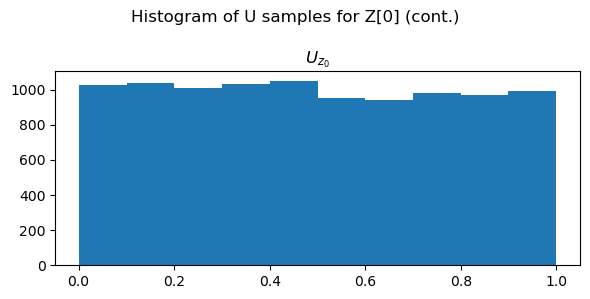

In [17]:
fig, ax = plt.subplots(figsize=(6,3))
fig.suptitle('Histogram of U samples for Z[0] (cont.)')
ax.hist(z_res['u_z_cont'][:,0])
ax.set_title(r'$U_{z_0}$')
plt.tight_layout()
plt.show()



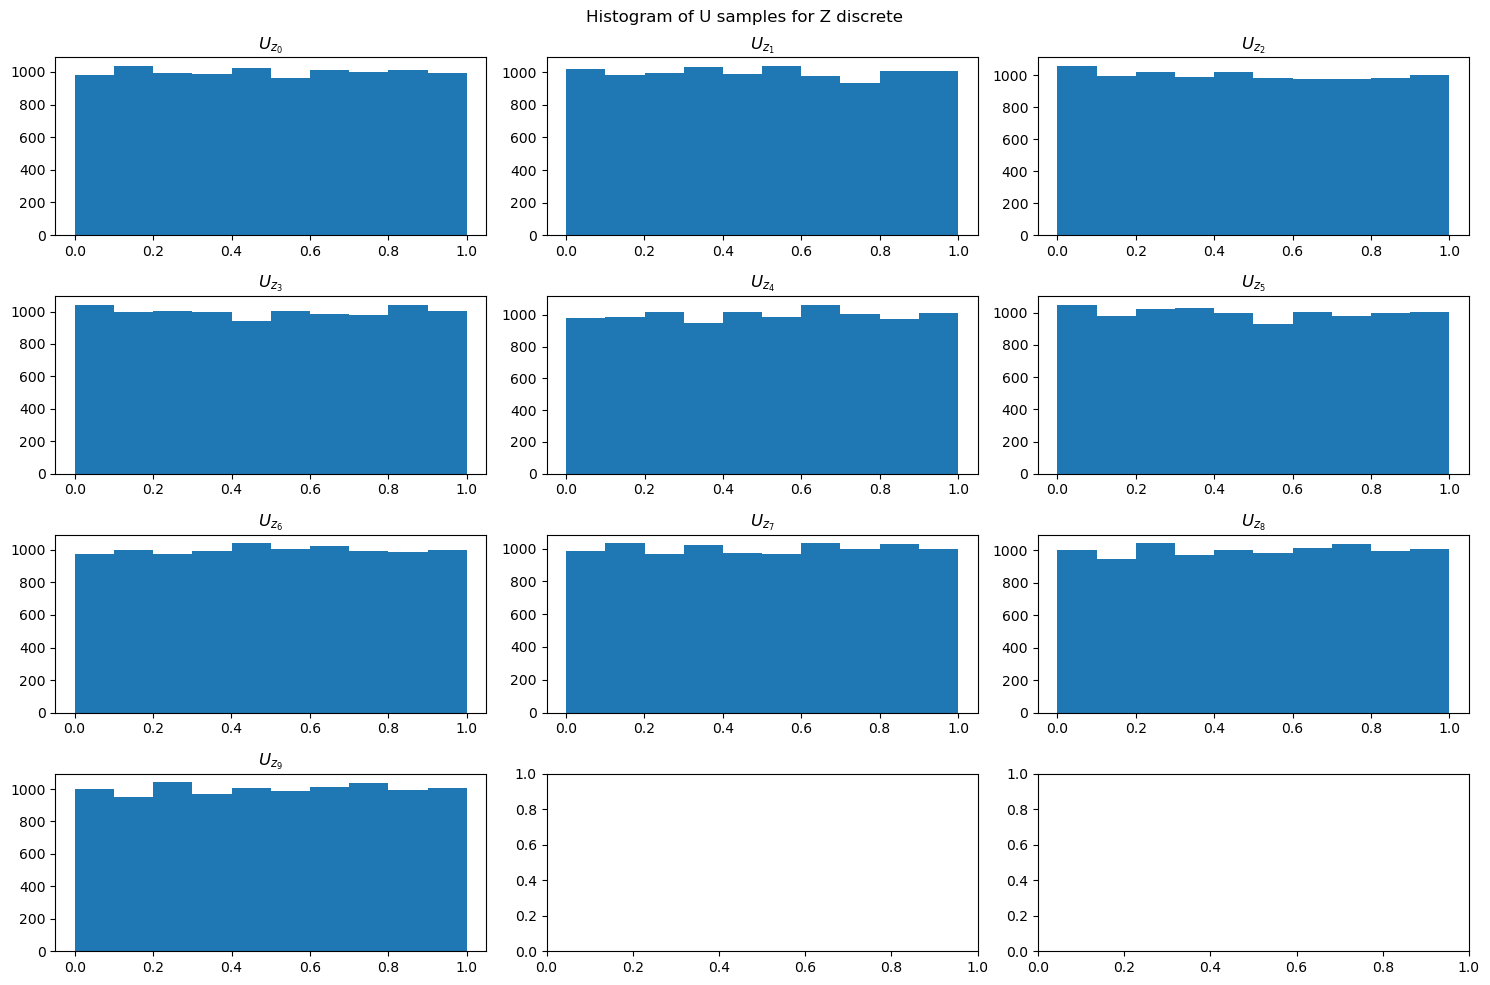

In [18]:
n_z_discr = z_res['u_z_discr'].shape[-1]

fig, ax = plt.subplots(4,3, figsize=(15,10))
fig.suptitle('Histogram of U samples for Z discrete')

for a_ix, a in enumerate(ax.flatten()[:-2]):
    a.hist(z_res['u_z_discr'][:,a_ix+1])
    a.set_title(r'$U_{z_{' + str(a_ix) + r'}}$')
plt.tight_layout()
plt.show()

## Univariate Frugal Flow

In [24]:
Y1 = data["Y"][:,23, None] 

In [25]:
Y1.shape

(10000, 1)

In [26]:
data["Y"].shape

(10000, 64)

In [27]:
key, subkey = jr.split(key)
frugal_flow, losses = train_frugal_flow(key=subkey,
                y=Y1,
                u_z=u_z,
                learning_rate=1e-2,
                max_patience=200,
                max_epochs=20,
                causal_model_args={'ate':jnp.array([5.]), 'const':2, 'scale':1.},
                condition=data["X"],
             )



100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:22<00:00,  1.14s/it, train=0.815, val=1.3]


In [28]:
frugal_flow.bijection[-1].bijection.bijections[0].ate

Array([0.41137832], dtype=float32)

In [29]:
gauss_bij= frugal_flow.bijection[-1].bijection.bijections[0]

In [33]:
import paramax
paramax.unwrap(gauss_bij).ate, paramax.unwrap(gauss_bij).scale


(Array([0.41137832], dtype=float32), Array(2.0819528, dtype=float32))

In [34]:
data["ATE"][23]

Array(0.00249897, dtype=float32)

In [35]:
np.argmax(data["ATE"])

Array(44, dtype=int32)

## Multivariate flow

In [36]:
Y = data["Y"]

In [37]:
Y.shape

(10000, 64)

In [38]:
data["X"].shape

(10000, 1)

In [39]:
key, subkey = jr.split(key)
frugal_flow, losses = train_frugal_flow(
    causal_model="location_translation",
    key=subkey,
    y=Y,
    u_z=u_z,  # impose discrete
    learning_rate=5e-4,
    max_epochs=10,
    max_patience=40,
    batch_size=100,
    condition=data["X"],
    causal_model_args={"ate":3.0, "RQS_knots":8, "nn_depth":1, "nn_width":50, "flow_layers":4},
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:15<00:00,  7.55s/it, train=-5.8, val=-5.86]


In [41]:
loccond_block = frugal_flow.bijection.bijections[5]
tau_hat = jnp.array([float(paramax.unwrap(loccond_block.bijections[k]).ate) for k in range(64)])
print(" tau_hat:", tau_hat)

 tau_hat: [2.8246384 2.7671344 2.833352  2.833692  2.5252867 2.5489058 2.9056346
 2.924818  2.84231   2.883085  2.85784   2.7725637 2.832136  2.87367
 2.614048  2.7887273 2.8610284 2.727376  2.8642128 2.8846774 2.9157712
 2.758526  2.8828828 2.8446026 2.7743125 2.8862815 2.9028497 2.8627536
 2.8698087 2.742658  2.6768909 2.8492153 2.888797  2.7518005 2.6607423
 2.8507273 2.9485948 2.7968526 2.6997204 2.8804045 2.926999  2.9130366
 2.7372134 2.902547  2.935125  2.7358606 2.6281185 2.8421738 2.811381
 2.8407476 2.7646248 2.8887706 2.692548  2.8227243 2.7286546 2.814025
 2.899194  2.7497737 2.8396935 2.889585  2.9383707 2.5439425 2.7781672
 2.7947092]


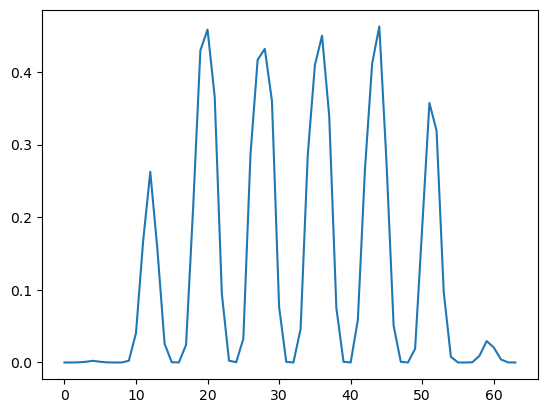

In [43]:
plt.plot(data["ATE"])

# Explore data

max |ITE|: 0.83849645
nonzero fraction: 0.17704296875
per-unit nonzero pixels: [29 33 32 66 52 38 35 37 68 50]


Text(0.5, 1.0, 'mean |ITE| per pixel')

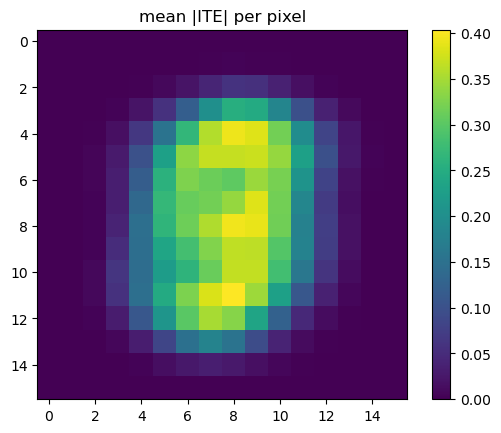

In [20]:
ITE = np.asarray(data["ITE"])
print("max |ITE|:", np.abs(ITE).max())
print("nonzero fraction:", (ITE != 0).mean())          # expect roughly the ink fraction, ~0.15–0.3
print("per-unit nonzero pixels:", (ITE != 0).sum(axis=1)[:10])
plt.imshow(np.abs(ITE).mean(axis=0).reshape(SIZE, SIZE)); plt.colorbar()
plt.title("mean |ITE| per pixel")  # should light up where digits are

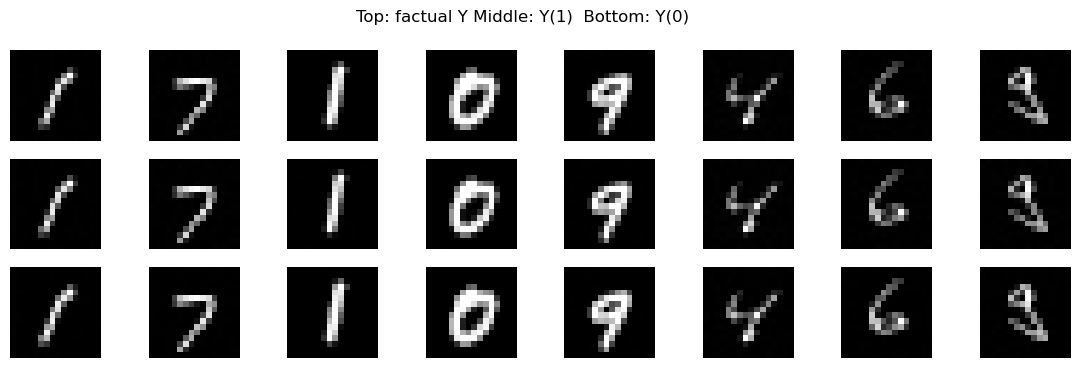

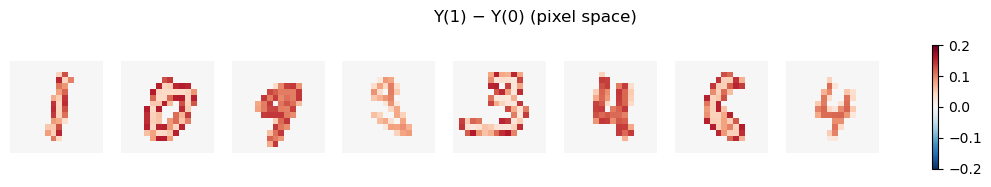

In [24]:
fig, axes = plt.subplots(3, 8, figsize=(14, 4))
imgs = inverse_logit(np.asarray(data["Y"][:8]))          # back to [0,1]
for i, ax in enumerate(axes[0]):
    ax.imshow(unflatten(imgs[i], SIZE)[0], cmap="gray"); ax.axis("off")
axes[0, 0].set_ylabel("factual", rotation=0)

# untreated potential outcome for the same units
imgs0 = inverse_logit(np.asarray(data["Y0"][:8]))
for i, ax in enumerate(axes[1]):
    ax.imshow(unflatten(imgs0[i], SIZE)[0], cmap="gray"); ax.axis("off")

# treated potential outcome for the same units
imgs1 = inverse_logit(np.asarray(data["Y1"][:8]))
for i, ax in enumerate(axes[2]):
    ax.imshow(unflatten(imgs1[i], SIZE)[0], cmap="gray"); ax.axis("off")
plt.suptitle("Top: factual Y Middle: Y(1)  Bottom: Y(0)")
plt.show()


T = np.asarray(data["X"]).flatten().astype(bool)
diff = inverse_logit(np.asarray(data["Y1"])) - inverse_logit(np.asarray(data["Y0"]))

idx = np.where(T)[0][:8]
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in zip(idx, axes):
    im = ax.imshow(diff[i].reshape(SIZE, SIZE), cmap="RdBu_r",
                   vmin=-0.2, vmax=0.2)
    ax.axis("off")
plt.suptitle("Y(1) − Y(0) (pixel space)")
plt.colorbar(im, ax=axes, shrink=0.8)
plt.show()

treated fraction: 0.493


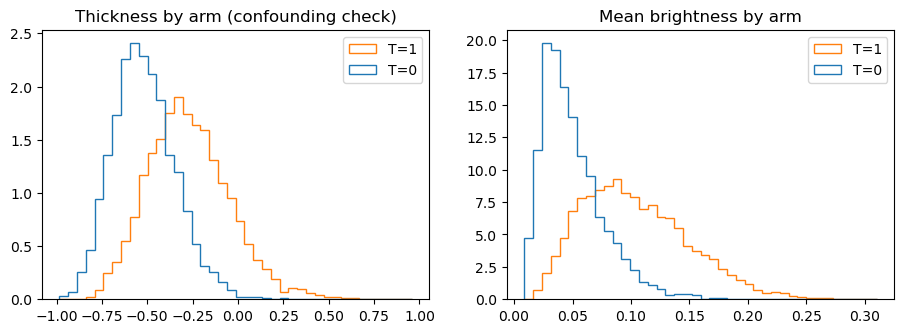

In [8]:
T = np.asarray(data["X"]).flatten()
thickness = np.asarray(data["Z"])[:, 0]
print(f"treated fraction: {T.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist([thickness[T==0], thickness[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[0].legend(); axes[0].set_title("Thickness by arm (confounding check)")

# naive vs adjusted difference in mean brightness
mean_bright = inverse_logit(Y).mean(axis=1)
axes[1].hist([mean_bright[T==0], mean_bright[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[1].legend(); axes[1].set_title("Mean brightness by arm")
plt.show()

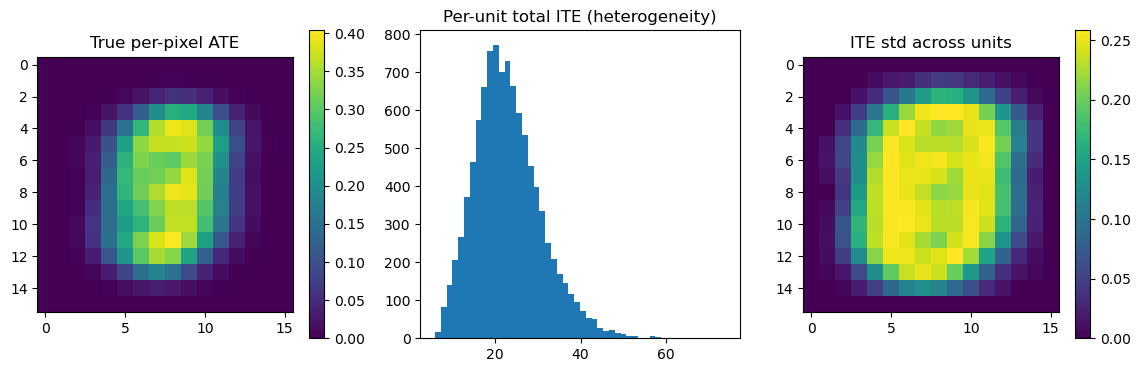

In [9]:
ATE = np.asarray(data["ATE"])           # (K,)
ITE = np.asarray(data["ITE"])           # (n, K)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im = axes[0].imshow(ATE.reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[0])
axes[0].set_title("True per-pixel ATE")

axes[1].hist(ITE.sum(axis=1), bins=50)
axes[1].set_title("Per-unit total ITE (heterogeneity)")

im = axes[2].imshow(ITE.std(axis=0).reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[2])
axes[2].set_title("ITE std across units")
plt.show()

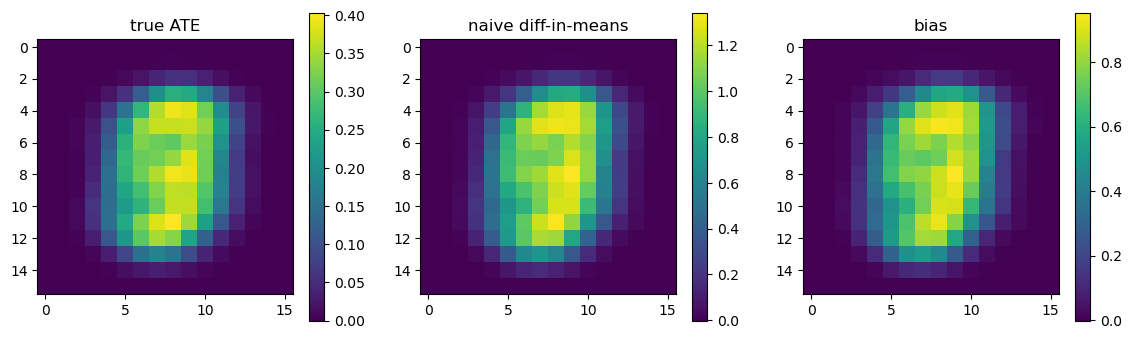

mean |bias| = 0.2186


In [10]:
# Naive per-pixel difference of means — biased because T is confounded
naive = Y[T==1].mean(axis=0) - Y[T==0].mean(axis=0)
true_flowspace = ITE.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, v, title in zip(axes, [true_flowspace, naive, naive - true_flowspace],
                        ["true ATE", "naive diff-in-means", "bias"]):
    im = ax.imshow(v.reshape(SIZE, SIZE)); plt.colorbar(im, ax=ax); ax.set_title(title)
plt.show()
print(f"mean |bias| = {np.abs(naive - true_flowspace).mean():.4f}")